#### Import Libraries and Dataset

In [1]:
!pip install wordcloud

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [3]:
df_credits = pd.read_csv('tmdb_5000_credits.csv')
df_movies = pd.read_csv('tmdb_5000_movies.csv')
original_df_movies = df_movies.copy()

The tmdb_5000_credits.csv file in the TMDB 5000 Movie Dataset typically contains information about the cast and crew of the movies. If your current analysis focuses primarily on movie genres, you may not need this part of the dataset immediately.

However, if you plan to explore aspects related to cast, crew, or any collaborative filtering methods (like recommending movies based on similar cast or crew), you might want to revisit and incorporate the credits data later.

For now, you can proceed with the tmdb_5000_movies.csv file for your initial analysis and questions related to movie genres. Later, if you decide to explore more aspects of the dataset, you can bring in the credits data accordingly.

In [4]:
df_movies.info()

#see the column info and null values in the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

In [5]:
# release_date column is an object. we need the change that to date type.

df_movies['release_date'] = pd.to_datetime(df_movies['release_date'])

In [6]:
df_movies.isnull().sum()

budget                     0
genres                     0
homepage                3091
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
dtype: int64

In [7]:
df_movies.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


#### First thing first, we need understand our dataset and make it useful so that we can manipulate it comfortably. This is where we start

Based on the dataset's information, the columns that seem relevant for initial exploratory data analysis (EDA) and movie genre-related questions could include:

***genres***: This column contains information about the genres of the movies, which is crucial for your genre-based analysis.
***release_date***: You might want to explore trends or patterns related to the release dates of movies.
***popularity***: Analyzing popularity might provide insights into audience preferences.
***voteaverage***: This column represents the average vote given to the movie, which can be an indicator of the movie's overall quality.
***vote_count***: The number of votes cast for a movie could also be relevant in assessing its popularity.
***budget***: The budget of a movie might be interesting in exploring the relationship between budget and popularity.
***revenue***: Similar to budget, revenue could be important for understanding the financial success of movies.
***keywords***: Keywords associated with movies might provide additional context for their content.
***production_companies***: You can explore the involvement of different production companies in producing movies.
***production_countries***: Analyzing the countries where movies are produced could be interesting.

The decision to drop or keep columns depends on the specific goals of your analysis. Here are some considerations for the other columns:

***homepage, overview, tagline***: These columns contain text-based information that might not be directly relevant to your initial analysis. If you're not planning to perform natural language processing (NLP) tasks, you might consider dropping them.
***id***: If this column is just an identifier and doesn't carry meaningful information for your analysis, you can drop it.
***original_language***: This column could be relevant if you're interested in exploring movies based on their original language.
***original_title, title***: Depending on your analysis goals, you might choose one of these columns. If they represent the same information, you can drop one of them.
***runtime***: The duration of a movie might be interesting to explore, but it depends on your analysis goals.
***spoken_languages, status***: Similar to original_language, these columns might be relevant based on your specific analysis.

In [8]:
# I do not plan to trade with these columns. Others can be decided according to the purpose.

df_movies.drop(['id','homepage','tagline','keywords', 'status', 'original_title'], axis=1, inplace=True)

In [9]:
#remove rows with null values. If I had done this before the drop operation, we would have lost many of our rows.

df_movies.dropna(inplace = True)
df_movies.isnull().sum()
df_movies.shape

(4799, 14)

##### If we look at the columns 'production_companies, production_countries, genres, spoken_languages' we will see a mess. It's not useful that way. We only need to capture information that will be useful to us. We will use the 'name' key to capture the information we want.

In [10]:
df_movies.iloc[0].genres

'[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 14, "name": "Fantasy"}, {"id": 878, "name": "Science Fiction"}]'

In [11]:
import ast #for converting str to list

def convert(text):
    L = []
    for i in ast.literal_eval(text):
        L.append(i['name']) 
    return L


def convert_cast(text):
    L = []
    counter = 0
    for i in ast.literal_eval(text):
        if counter < 3:
            L.append(i['name'])
        counter+=1
    return L


def crew_director(text):
    L = []
    for i in ast.literal_eval(text):
        if i['job'] == 'Director':
            L.append(i['name'])
            break
    return L

In [12]:
df_movies['genres'] = df_movies['genres'].apply(convert)
df_movies['production_companies'] = df_movies['production_companies'].apply(convert)
df_movies['production_countries'] = df_movies['production_countries'].apply(convert)
df_movies['spoken_languages'] = df_movies['spoken_languages'].apply(convert)

In [13]:
df_movies.head()

,budget,genres,original_language,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,title,vote_average,vote_count
0,237000000,"[Action, Adventure, Fantasy, Science Fiction]",en,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[Ingenious Film Partners, Twentieth Century Fo...","[United States of America, United Kingdom]",2009-12-10,2787965087,162.0,"[English, Español]",Avatar,7.2,11800
1,300000000,"[Adventure, Fantasy, Action]",en,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[Walt Disney Pictures, Jerry Bruckheimer Films...",[United States of America],2007-05-19,961000000,169.0,[English],Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[Action, Adventure, Crime]",en,A cryptic message from Bond’s past sends him o...,107.376788,"[Columbia Pictures, Danjaq, B24]","[United Kingdom, United States of America]",2015-10-26,880674609,148.0,"[Français, English, Español, Italiano, Deutsch]",Spectre,6.3,4466
3,250000000,"[Action, Crime, Drama, Thriller]",en,Following the death of District Attorney Harve...,112.312950,"[Legendary Pictures, Warner Bros., DC Entertai...",[United States of America],2012-07-16,1084939099,165.0,[English],The Dark Knight Rises,7.6,9106
4,260000000,"[Action, Adventure, Science Fiction]",en,"John Carter is a war-weary, former military ca...",43.926995,[Walt Disney Pictures],[United States of America],2012-03-07,284139100,132.0,[English],John Carter,6.1,2124


##### Again, after this point, many breakdowns can be made regarding the direction in which we will take our analysis. We can already work with numerical columns as we wish.  It is also up to us how we will work with columns containing more than one string values. For example, will we use a single value in a column or will we use the top 3? We can only include the 'cast' column in the 'tmdb_5000_credits.csv' dataset in our case, create a new dataset from it, and work on it only. There will be no end to this. For this reason, let's try to find answers to the questions we have previously determined.

### 1.	What is the distribution of movie genres in the dataset?

In [14]:
# Function to get top N genres (I want to choose 3)
# In this version, the explode() function is used to transform the 'genres' column with lists into a long format,
# and then the top genres are extracted. 

def get_top_genres(df, n=3):
    # Drop rows with missing or empty 'genres', If you don't do this it will return empty result.
    df = df_movies.dropna(subset=['genres'])
    df = df[df_movies['genres'].apply(len) > 0]
    
    # Replace this with your logic for extracting top genres
    top_genres = df['genres'].explode().value_counts().index[:n]
    return top_genres

In [15]:
top_genres = get_top_genres(df_movies, n=5)

In [16]:
for genre in top_genres:
    df_movies[genre] = df_movies['genres'].apply(lambda x: 1 if genre in str(x) else 0)

Top Genres: Index(['Drama', 'Comedy', 'Thriller', 'Action', 'Romance'], dtype='object')
Genre Distribution: Drama       2296
Comedy      1722
Thriller    1274
Action      1154
Romance      894
dtype: int64


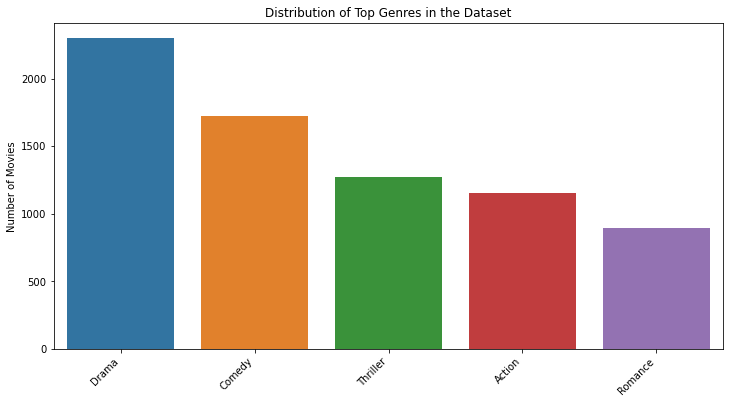

In [17]:
# Bar chart for the distribution of top genres

print(f"Top Genres: {top_genres}")
print(f"Genre Distribution: {df_movies[top_genres].sum().sort_values(ascending=False)}")


genre_distribution = df_movies[top_genres].sum().sort_values(ascending=False)

# Check if the genre_distribution is not empty
if not genre_distribution.empty:
    plt.figure(figsize=(12, 6))
    sns.barplot(x=genre_distribution.index, y=genre_distribution.values)
    plt.title('Distribution of Top Genres in the Dataset')
    plt.ylabel('Number of Movies')
    plt.xticks(rotation=45, ha='right')
    plt.show()
else:
    print("No data available for plotting.")

In [18]:
# Let's solve the problem once and for all so that it doesn't cause problems every time!

# Drop rows with missing or empty 'genres'

df_movies = df_movies.dropna(subset=['genres'])
df_movies = df_movies[df_movies['genres'].apply(len) > 0]

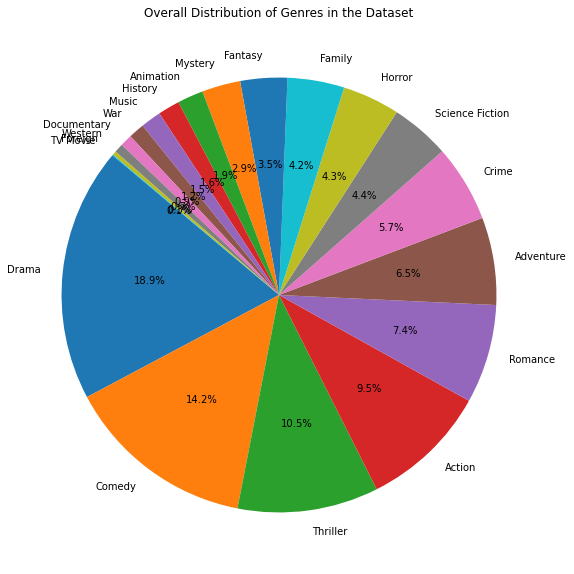

In [19]:
# Pie chart for the overall distribution of genres

def get_overall_genre_distribution(df):
    
    # Flatten the 'genres' lists
    all_genres = df_movies['genres'].explode()

    # Calculate genre distribution
    genre_distribution = all_genres.value_counts()
    return genre_distribution

overall_genre_distribution = get_overall_genre_distribution(df_movies)

if not overall_genre_distribution.empty:
    plt.figure(figsize=(10, 10))
    plt.pie(overall_genre_distribution, labels=overall_genre_distribution.index, autopct='%1.1f%%', startangle=140)
    plt.title('Overall Distribution of Genres in the Dataset')
    plt.show()
else:
    print("No data available for plotting.")

###### How about escalating things a little more?  Let's add a little more color to the question and explore how the distribution of movie genres changes over time. If you remember, we corrected the data type of our 'release_date' column. Now we can work using this. 

In [20]:
# Extract year from release date

df_movies['release_year'] = df_movies['release_date'].dt.year

In [21]:
df_movies_exploded = df_movies.explode('genres')

In [22]:
# Count the occurrences of each genre per year

genre_counts_by_year = df_movies_exploded.groupby(['release_year', 'genres']).size().unstack().fillna(0)

Plot saved as temporal_trends_plot.png


<Figure size 2160x1080 with 0 Axes>

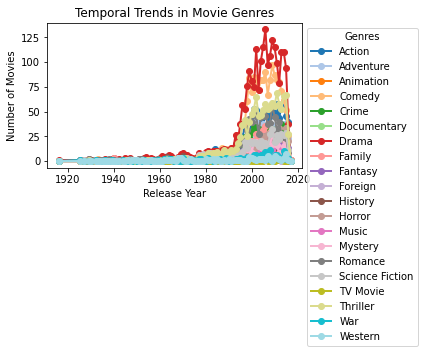

In [23]:
plt.figure(figsize=(30, 15))
genre_counts_by_year.plot(kind='line', marker='o', cmap='tab20', linewidth=2)
plt.title('Temporal Trends in Movie Genres')
plt.xlabel('Release Year')
plt.ylabel('Number of Movies')
plt.legend(title='Genres', bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()

plt.savefig("temporal_trends_plot.png", bbox_inches='tight')

# Display a message indicating that the plot has been saved
print("Plot saved as temporal_trends_plot.png");

In [24]:
import plotly.express as px

df_long = genre_counts_by_year.reset_index().melt(id_vars='release_year', var_name='Genre', value_name='Number of Movies')

# Create an interactive line plot using Plotly Express
fig = px.line(df_long, x='release_year', y='Number of Movies', color='Genre',
              title='Temporal Trends in Movie Genres', labels={'release_year': 'Release Year', 'Number of Movies': 'Number of Movies'},
              width=1000, height=600)

fig.show()

###### 2.	How does the distribution of movie budgets look? Are there any outliers?

####### To analyze the distribution of movie budgets and identify outliers, we can use descriptive statistics and visualizations.

In [25]:
df_movies['budget'].describe()

count    4.772000e+03
mean     2.922961e+07
std      4.078925e+07
min      0.000000e+00
25%      9.500000e+05
50%      1.500000e+07
75%      4.000000e+07
max      3.800000e+08
Name: budget, dtype: float64

In [26]:
import locale

locale.setlocale(locale.LC_ALL, '')

formatted_stats = df_movies['budget'].describe().apply(lambda x: locale.format_string("%.2f", x, grouping=True))
print(formatted_stats)

count          4.772,00
mean      29.229.613,06
std       40.789.250,15
min                0,00
25%          950.000,00
50%       15.000.000,00
75%       40.000.000,00
max      380.000.000,00
Name: budget, dtype: object


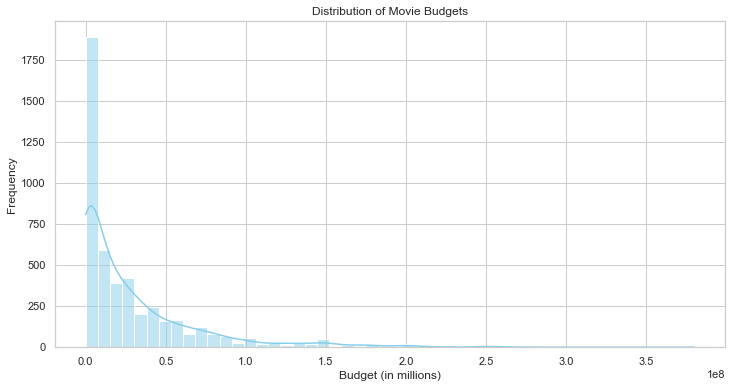

In [27]:
sns.set(style="whitegrid")

# Plot the distribution of movie budgets
plt.figure(figsize=(12, 6))
sns.histplot(df_movies['budget'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Movie Budgets')
plt.xlabel('Budget (in millions)')
plt.ylabel('Frequency')
plt.show();

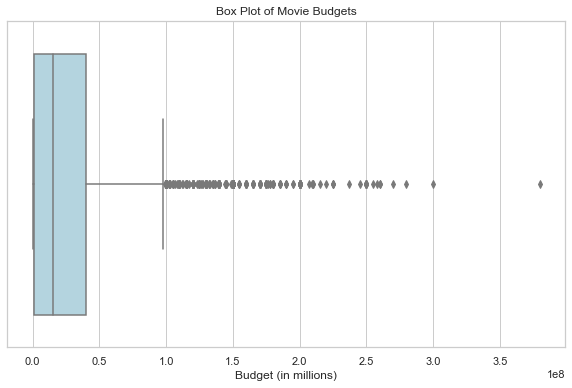

In [28]:
# Plot a box plot to identify outliers

plt.figure(figsize=(10, 6))
sns.boxplot(x=df_movies['budget'], color='lightblue')
plt.title('Box Plot of Movie Budgets')
plt.xlabel('Budget (in millions)')
plt.show();

In [29]:
from scipy.stats import zscore

# Calculate Z-scores for the budget column
df_movies['budget_zscore'] = zscore(df_movies['budget'])

# Filter out rows with Z-scores beyond a threshold (e.g., 3)
outliers = df_movies[abs(df_movies['budget_zscore']) > 3]
print("Outliers:")
print(outliers[['title', 'budget']])

Outliers:
                                        title     budget
0                                      Avatar  237000000
1    Pirates of the Caribbean: At World's End  300000000
2                                     Spectre  245000000
3                       The Dark Knight Rises  250000000
4                                 John Carter  260000000
..                                        ...        ...
112                                 Alexander  155000000
126                      Thor: The Dark World  170000000
145                                      Troy  175000000
208                          The 13th Warrior  160000000
259                   Speed 2: Cruise Control  160000000

[103 rows x 2 columns]


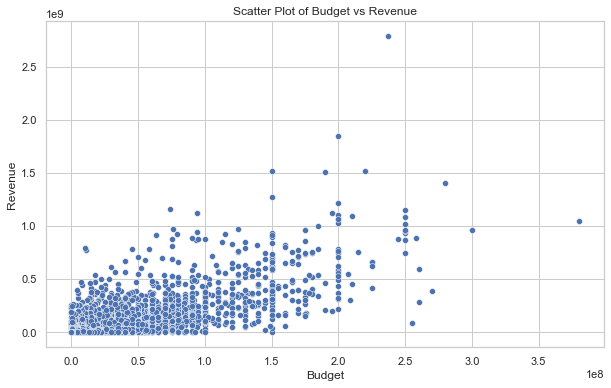

In [30]:
# Scatter plot of budget against another variable (e.g., revenue)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='budget', y='revenue', data=df_movies)
plt.title('Scatter Plot of Budget vs Revenue')
plt.xlabel('Budget')
plt.ylabel('Revenue')
plt.show();

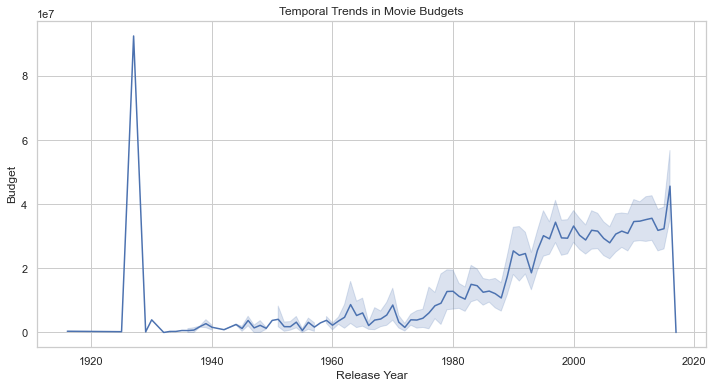

In [31]:
# Line plot of budget trends over release years

plt.figure(figsize=(12, 6))
sns.lineplot(x='release_year', y='budget', data=df_movies)
plt.title('Temporal Trends in Movie Budgets')
plt.xlabel('Release Year')
plt.ylabel('Budget')
plt.show();

###### As a result of the z-score we received, a few films were perceived as outliers due to their high and low budgets. However, when we look at it from a domain knowlodge perspective, the movies mentioned are really high-budget movies. On the other hand, movies that appear to be low-budget according to the dataframe may have remained low-budget depending on the year they were shot.

##### 3.	What is the average runtime of movies in the dataset?

In [32]:
# Calculate the average runtime
average_runtime = df_movies['runtime'].mean()

# Display the result
print(f'The average runtime of movies in the dataset is: {average_runtime:.2f} minutes')

The average runtime of movies in the dataset is: 107.21 minutes


###### Oh! We found the answer to the question, but it seems quite simple. Let's see what more we can do.

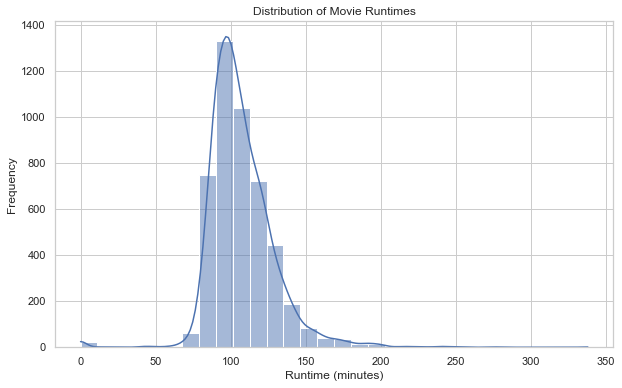

In [33]:
# Plot the histogram of runtimes

plt.figure(figsize=(10, 6))
sns.histplot(df_movies['runtime'], bins=30, kde=True)
plt.title('Distribution of Movie Runtimes')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Frequency')
plt.show();

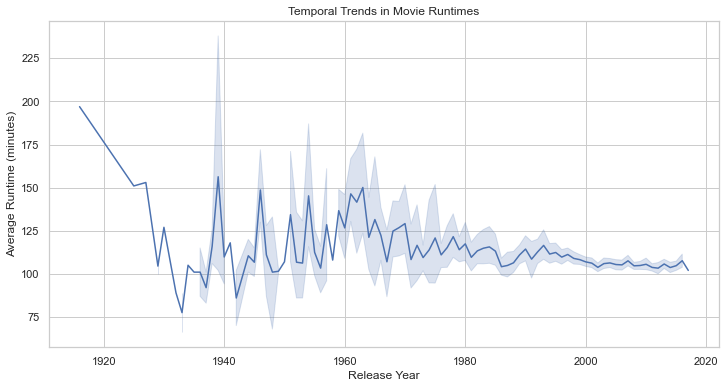

In [34]:
# Line plot of average runtime over release years

plt.figure(figsize=(12, 6))
sns.lineplot(x='release_year', y='runtime', data=df_movies)
plt.title('Temporal Trends in Movie Runtimes')
plt.xlabel('Release Year')
plt.ylabel('Average Runtime (minutes)')
plt.show();

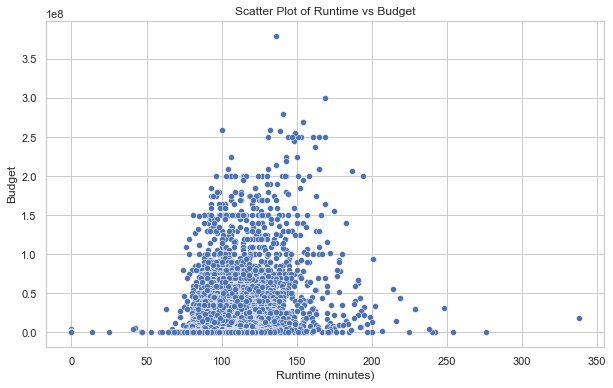

In [35]:
# Scatter plot of runtime against budget

plt.figure(figsize=(10, 6))
sns.scatterplot(x='runtime', y='budget', data=df_movies)
plt.title('Scatter Plot of Runtime vs Budget')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Budget')
plt.show();

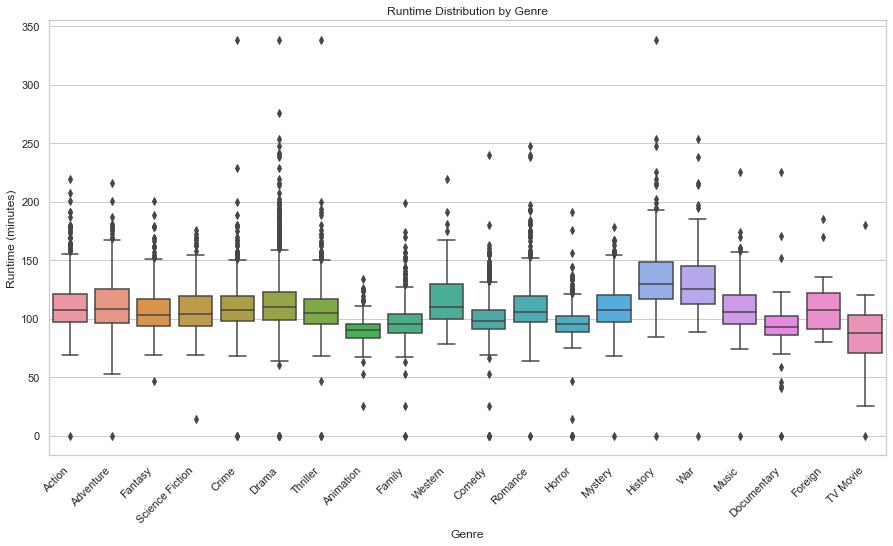

In [36]:
# Box plot of runtime by genre

df_exploded_genres = df_movies.explode('genres')

plt.figure(figsize=(15, 8))
sns.boxplot(x='genres', y='runtime', data=df_exploded_genres)
plt.title('Runtime Distribution by Genre')
plt.xlabel('Genre')
plt.ylabel('Runtime (minutes)')
plt.xticks(rotation=45, ha='right')
plt.show();

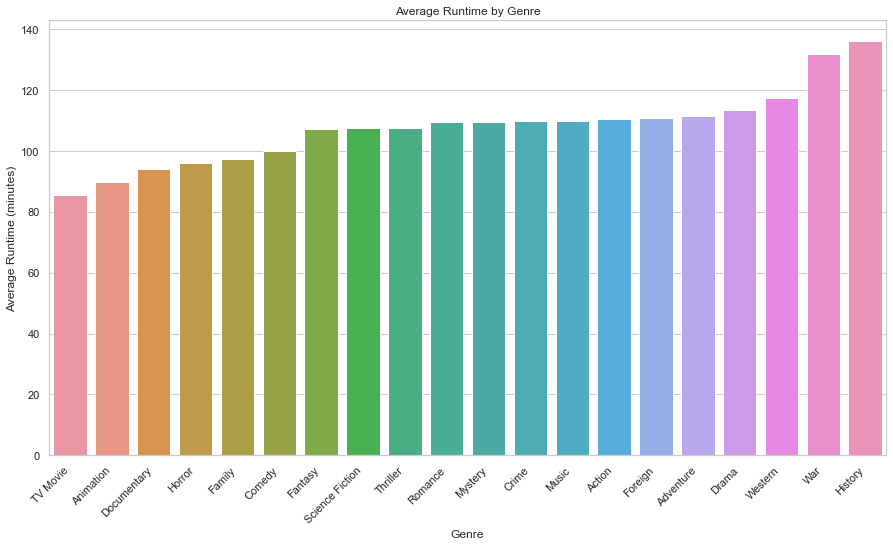

In [37]:
# Calculate the average runtime for each genre
average_runtime_by_genre = df_exploded_genres.groupby('genres')['runtime'].mean().sort_values()

# Bar plot of average runtime by genre
plt.figure(figsize=(15, 8))
sns.barplot(x=average_runtime_by_genre.index, y=average_runtime_by_genre.values)
plt.title('Average Runtime by Genre')
plt.xlabel('Genre')
plt.ylabel('Average Runtime (minutes)')
plt.xticks(rotation=45, ha='right')
plt.show()

In [38]:
# Calculate median and quartiles

median_runtime = df_movies['runtime'].median()
q1 = df_movies['runtime'].quantile(0.25)
q3 = df_movies['runtime'].quantile(0.75)

print(f'Median Runtime: {median_runtime:.2f} minutes')
print(f'Q1 (25th percentile): {q1:.2f} minutes')
print(f'Q3 (75th percentile): {q3:.2f} minutes')

Median Runtime: 104.00 minutes
Q1 (25th percentile): 94.00 minutes
Q3 (75th percentile): 118.00 minutes


##### 4.	What are the key factors influencing the popularity of movies in the dataset, and how do these factors contribute to the distribution of popularity scores?

###### Investigate potential factors that could influence the popularity of movies. This may include genres, budgets, release dates, and cast (we are not using this dataset now) members.

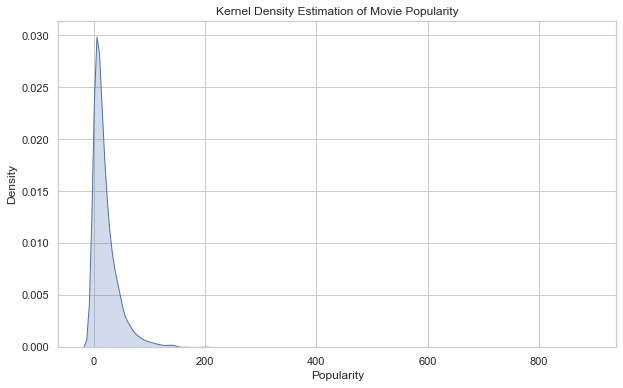

In [39]:
# KDE plot of movie popularity

plt.figure(figsize=(10, 6))
sns.kdeplot(df_movies['popularity'], fill=True)
plt.title('Kernel Density Estimation of Movie Popularity')
plt.xlabel('Popularity')
plt.ylabel('Density')
plt.show();

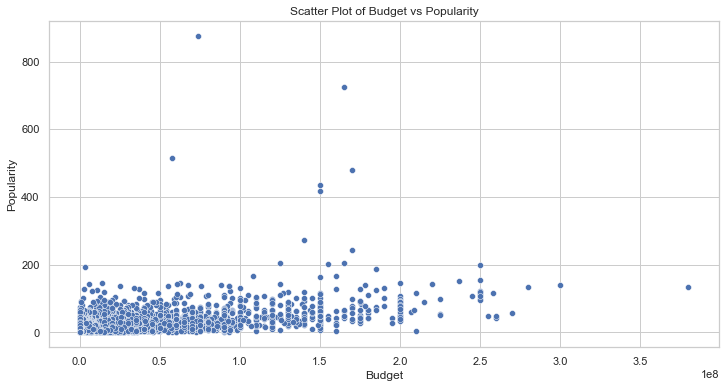

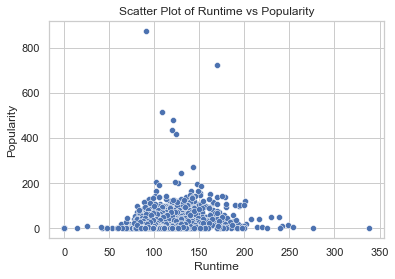

In [40]:
# Explore the relationship between popularity and other factors (e.g., budget, runtime)
plt.figure(figsize=(12, 6))

sns.scatterplot(x='budget', y='popularity', data=df_movies)
plt.title('Scatter Plot of Budget vs Popularity')
plt.xlabel('Budget')
plt.ylabel('Popularity')
plt.show()

sns.scatterplot(x='runtime', y='popularity', data=df_movies)
plt.title('Scatter Plot of Runtime vs Popularity')
plt.xlabel('Runtime')
plt.ylabel('Popularity')
plt.show()

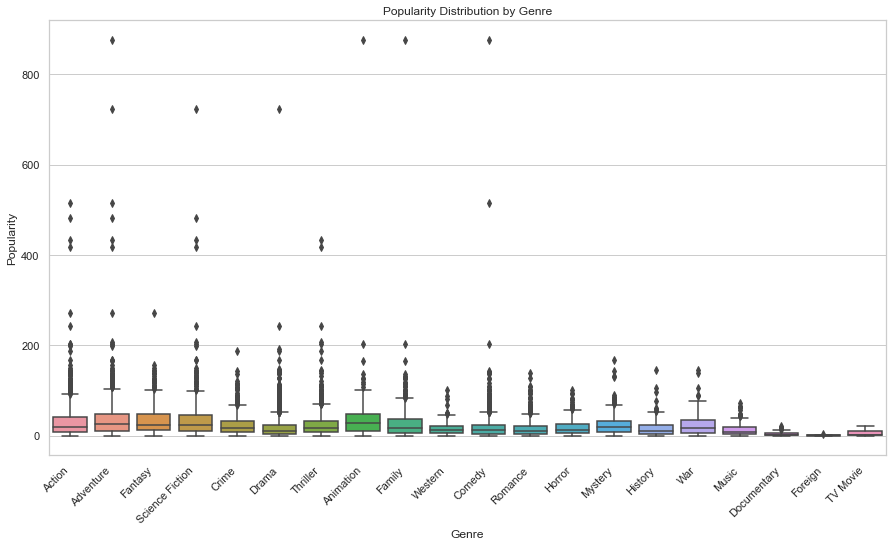

In [41]:
# Explode the 'genres' column to create a new row for each genre
df_genres = df_movies.explode('genres')

# Box plot of popularity by genre
plt.figure(figsize=(15, 8))
sns.boxplot(x='genres', y='popularity', data=df_genres)
plt.title('Popularity Distribution by Genre')
plt.xlabel('Genre')
plt.ylabel('Popularity')
plt.xticks(rotation=45, ha='right')
plt.show();

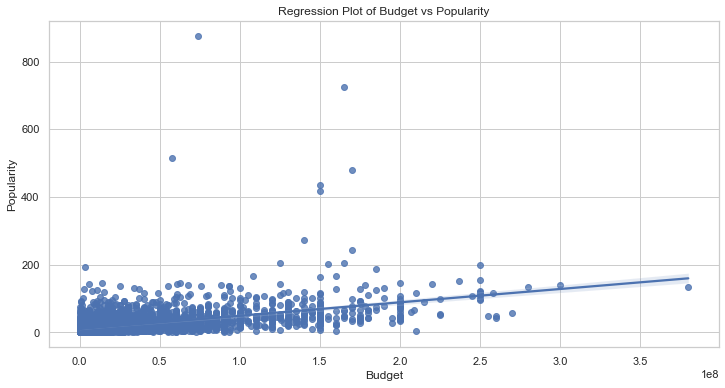

In [42]:
# Regression plot of budget and popularity

plt.figure(figsize=(12, 6))
sns.regplot(x='budget', y='popularity', data=df_movies)
plt.title('Regression Plot of Budget vs Popularity')
plt.xlabel('Budget')
plt.ylabel('Popularity')
plt.show();

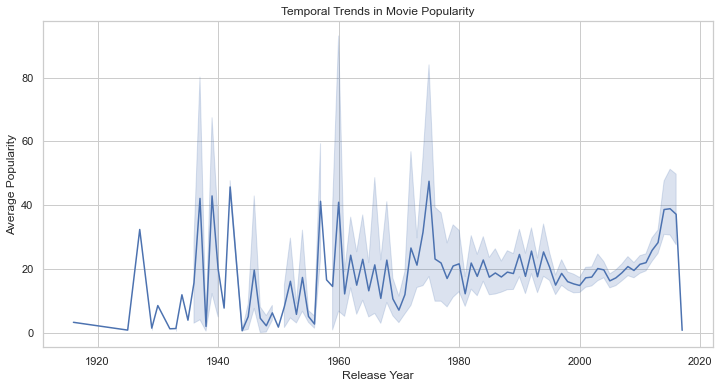

In [43]:
# Line plot of average popularity over release years

plt.figure(figsize=(12, 6))
sns.lineplot(x='release_year', y='popularity', data=df_movies)
plt.title('Temporal Trends in Movie Popularity')
plt.xlabel('Release Year')
plt.ylabel('Average Popularity')
plt.show()

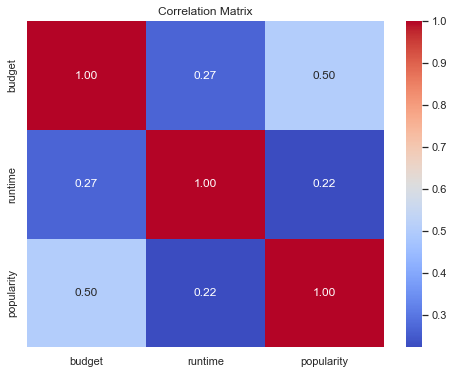

In [44]:
# Correlation matrix

correlation_matrix = df_movies[['budget', 'runtime', 'popularity']].corr()

# Heatmap of correlation matrix

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show();

##### 5.	Which directors have the highest average ratings for their movies?

###### Oh! So now is the time. We will need to combine two datasets. I was questioning why I didn't do this from the beginning.

In [45]:
df = df_movies.merge(df_credits, on = 'title')

df.head()

,budget,genres,original_language,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,...,Drama,Comedy,Thriller,Action,Romance,release_year,budget_zscore,movie_id,cast,crew
0,237000000,"[Action, Adventure, Fantasy, Science Fiction]",en,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[Ingenious Film Partners, Twentieth Century Fo...","[United States of America, United Kingdom]",2009-12-10,2787965087,162.0,...,0,0,0,1,0,2009,5.094287,19995,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[Adventure, Fantasy, Action]",en,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[Walt Disney Pictures, Jerry Bruckheimer Films...",[United States of America],2007-05-19,961000000,169.0,...,0,0,0,1,0,2007,6.638974,285,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[Action, Adventure, Crime]",en,A cryptic message from Bond’s past sends him o...,107.376788,"[Columbia Pictures, Danjaq, B24]","[United Kingdom, United States of America]",2015-10-26,880674609,148.0,...,0,0,0,1,0,2015,5.290438,206647,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[Action, Crime, Drama, Thriller]",en,Following the death of District Attorney Harve...,112.312950,"[Legendary Pictures, Warner Bros., DC Entertai...",[United States of America],2012-07-16,1084939099,165.0,...,1,0,1,1,0,2012,5.413032,49026,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[Action, Adventure, Science Fiction]",en,"John Carter is a war-weary, former military ca...",43.926995,[Walt Disney Pictures],[United States of America],2012-03-07,284139100,132.0,...,0,0,0,1,0,2012,5.658220,49529,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


###### I make these moves to make it easier to see.

###### After executing this code, the 'crew' and 'cast' columns in our DataFrame will be converted into lists of dictionaries, making it easier to work with the data. Each dictionary in the list represents information about a crew member or cast member.

###### You can then explore and analyze these columns based on your specific goals. I will continue by pulling certain features from this dictionary as we did before. 

In [46]:
df.iloc[0].cast

'[{"cast_id": 242, "character": "Jake Sully", "credit_id": "5602a8a7c3a3685532001c9a", "gender": 2, "id": 65731, "name": "Sam Worthington", "order": 0}, {"cast_id": 3, "character": "Neytiri", "credit_id": "52fe48009251416c750ac9cb", "gender": 1, "id": 8691, "name": "Zoe Saldana", "order": 1}, {"cast_id": 25, "character": "Dr. Grace Augustine", "credit_id": "52fe48009251416c750aca39", "gender": 1, "id": 10205, "name": "Sigourney Weaver", "order": 2}, {"cast_id": 4, "character": "Col. Quaritch", "credit_id": "52fe48009251416c750ac9cf", "gender": 2, "id": 32747, "name": "Stephen Lang", "order": 3}, {"cast_id": 5, "character": "Trudy Chacon", "credit_id": "52fe48009251416c750ac9d3", "gender": 1, "id": 17647, "name": "Michelle Rodriguez", "order": 4}, {"cast_id": 8, "character": "Selfridge", "credit_id": "52fe48009251416c750ac9e1", "gender": 2, "id": 1771, "name": "Giovanni Ribisi", "order": 5}, {"cast_id": 7, "character": "Norm Spellman", "credit_id": "52fe48009251416c750ac9dd", "gender": 

In [47]:
df.iloc[0].crew

'[{"credit_id": "52fe48009251416c750aca23", "department": "Editing", "gender": 0, "id": 1721, "job": "Editor", "name": "Stephen E. Rivkin"}, {"credit_id": "539c47ecc3a36810e3001f87", "department": "Art", "gender": 2, "id": 496, "job": "Production Design", "name": "Rick Carter"}, {"credit_id": "54491c89c3a3680fb4001cf7", "department": "Sound", "gender": 0, "id": 900, "job": "Sound Designer", "name": "Christopher Boyes"}, {"credit_id": "54491cb70e0a267480001bd0", "department": "Sound", "gender": 0, "id": 900, "job": "Supervising Sound Editor", "name": "Christopher Boyes"}, {"credit_id": "539c4a4cc3a36810c9002101", "department": "Production", "gender": 1, "id": 1262, "job": "Casting", "name": "Mali Finn"}, {"credit_id": "5544ee3b925141499f0008fc", "department": "Sound", "gender": 2, "id": 1729, "job": "Original Music Composer", "name": "James Horner"}, {"credit_id": "52fe48009251416c750ac9c3", "department": "Directing", "gender": 2, "id": 2710, "job": "Director", "name": "James Cameron"},

import json



df['crew'] = df['crew'].apply(lambda x: json.loads(x) if pd.notnull(x) else [])
df['cast'] = df['cast'].apply(lambda x: json.loads(x) if pd.notnull(x) else [])


df.head()

##### Now, Let's turn back to the question!

In [48]:
def crew_director(text):
    L = []
    for i in ast.literal_eval(text):
        if i['job'] == 'Director':
            L.append(i['name'])
            break
    return L

In [49]:
df['director'] = df['crew'].apply(crew_director)

In [50]:
df.head()

,budget,genres,original_language,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,...,Comedy,Thriller,Action,Romance,release_year,budget_zscore,movie_id,cast,crew,director
0,237000000,"[Action, Adventure, Fantasy, Science Fiction]",en,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[Ingenious Film Partners, Twentieth Century Fo...","[United States of America, United Kingdom]",2009-12-10,2787965087,162.0,...,0,0,1,0,2009,5.094287,19995,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",[James Cameron]
1,300000000,"[Adventure, Fantasy, Action]",en,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[Walt Disney Pictures, Jerry Bruckheimer Films...",[United States of America],2007-05-19,961000000,169.0,...,0,0,1,0,2007,6.638974,285,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",[Gore Verbinski]
2,245000000,"[Action, Adventure, Crime]",en,A cryptic message from Bond’s past sends him o...,107.376788,"[Columbia Pictures, Danjaq, B24]","[United Kingdom, United States of America]",2015-10-26,880674609,148.0,...,0,0,1,0,2015,5.290438,206647,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",[Sam Mendes]
3,250000000,"[Action, Crime, Drama, Thriller]",en,Following the death of District Attorney Harve...,112.312950,"[Legendary Pictures, Warner Bros., DC Entertai...",[United States of America],2012-07-16,1084939099,165.0,...,0,1,1,0,2012,5.413032,49026,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...",[Christopher Nolan]
4,260000000,"[Action, Adventure, Science Fiction]",en,"John Carter is a war-weary, former military ca...",43.926995,[Walt Disney Pictures],[United States of America],2012-03-07,284139100,132.0,...,0,0,1,0,2012,5.658220,49529,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de...",[Andrew Stanton]


In [51]:
director_avg_ratings = df.explode('director').groupby('director')['vote_average'].mean().sort_values(ascending=False)

director_avg_ratings.head(10)

director
Gary Sinyor             10.00
Lance Hool               9.30
Floyd Mutrux             8.50
Tim McCanlies            8.45
John Cromwell            8.40
Jem Cohen                8.30
Damien Chazelle          8.30
Philip Saville           8.20
Kevin Sullivan           8.20
Jorge Ramírez Suárez     8.10
Name: vote_average, dtype: float64

In [52]:
top_directors = director_avg_ratings.head(10)

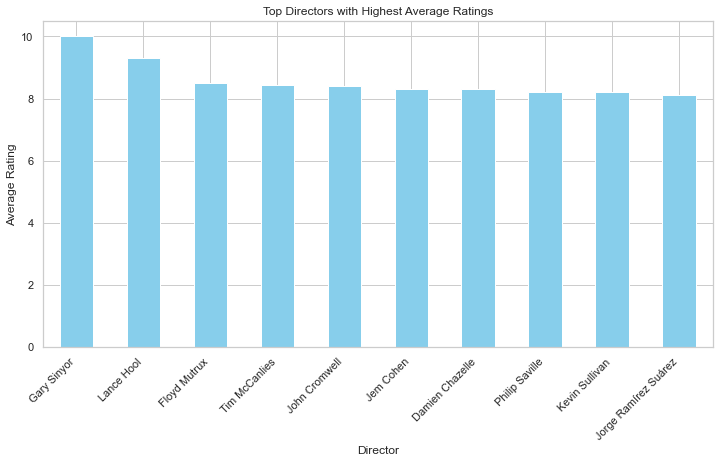

In [53]:
plt.figure(figsize=(12, 6))
top_directors.plot(kind='bar', color='skyblue')
plt.title('Top Directors with Highest Average Ratings')
plt.xlabel('Director')
plt.ylabel('Average Rating')
plt.xticks(rotation=45, ha='right')
plt.show();

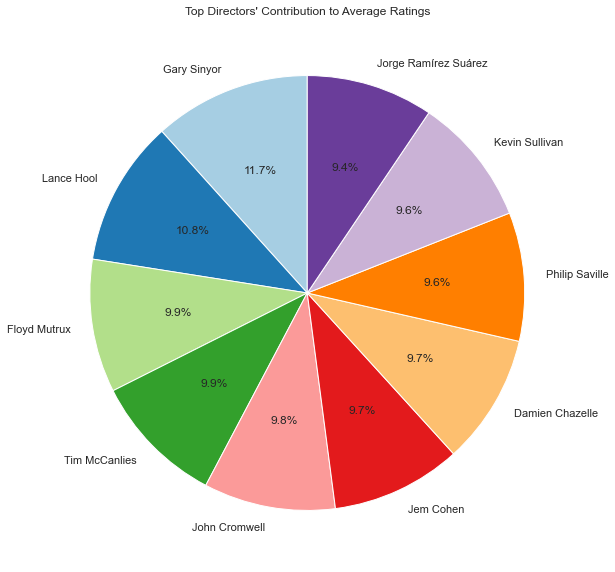

In [54]:
plt.figure(figsize=(10, 10))
plt.pie(top_directors, labels=top_directors.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired(range(len(top_directors))))
plt.title('Top Directors\' Contribution to Average Ratings')
plt.show()

##### 6.	Are there any trends in movie release over the years?

###### Number of Movies Released Each Year: A simple line or bar chart showing how the number of movie releases has changed over time.

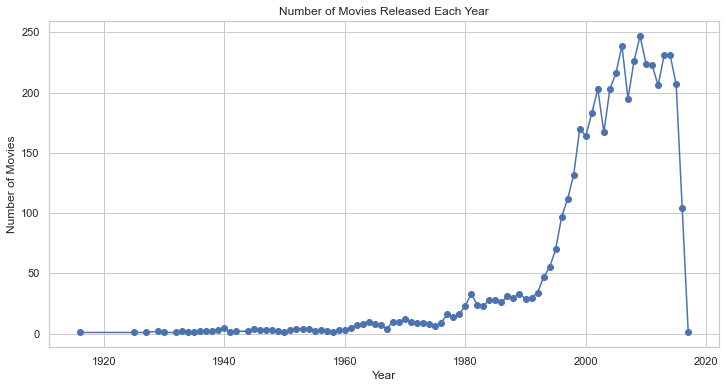

In [55]:
# Count the number of movies released each year
movies_per_year = df['release_year'].value_counts().sort_index()

# Plotting the number of movies released each year
plt.figure(figsize=(12, 6))
plt.plot(movies_per_year.index, movies_per_year.values, marker='o', linestyle='-')
plt.title('Number of Movies Released Each Year')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.grid(True)
plt.show();

###### Genre Distribution Over the Years: Are certain genres becoming more or less popular? We can create a stacked area chart or multiple bar charts to represent genre distributions each year.

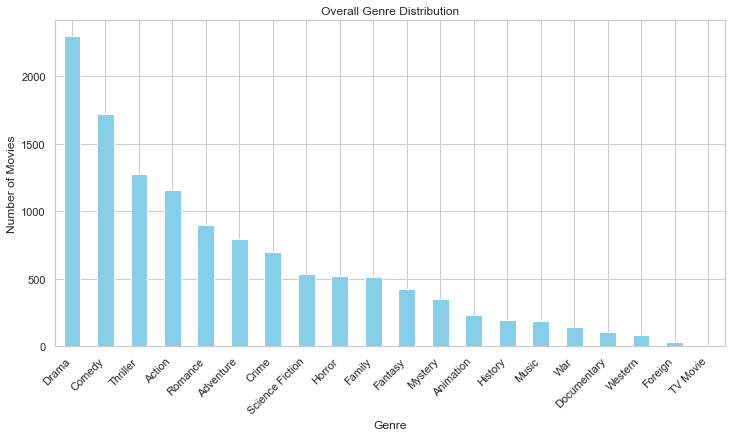

<Figure size 1152x576 with 0 Axes>

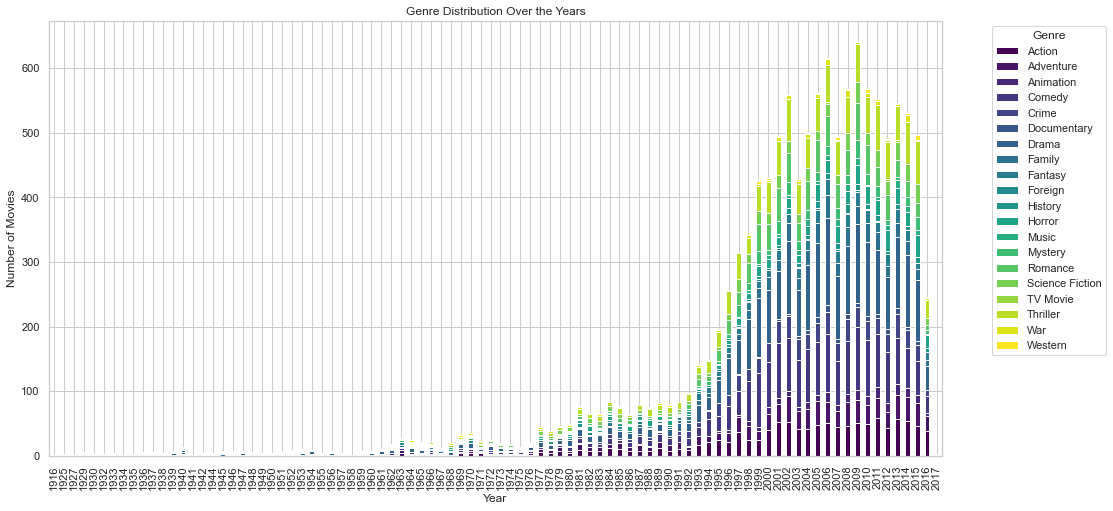

In [56]:
from collections import Counter

# Explode the 'genres' column. Yes again :)
exploded_genres = df.explode('genres')

# Count the number of movies per genre
genre_counts = exploded_genres['genres'].value_counts()

# Plotting the overall genre distribution
plt.figure(figsize=(12, 6))
genre_counts.plot(kind='bar', color='skyblue')
plt.title('Overall Genre Distribution')
plt.xlabel('Genre')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45, ha='right')
plt.show()

# Create a DataFrame for genre distribution over the years
genre_distribution_over_years = exploded_genres.groupby(['release_year', 'genres']).size().unstack().fillna(0)

# Plotting the genre distribution over the years
plt.figure(figsize=(16, 8))
genre_distribution_over_years.plot(kind='bar', stacked=True, colormap='viridis', figsize=(16, 8))
plt.title('Genre Distribution Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show();

##### 7.	What are the top 10 highest-grossing movies?

In [57]:
# Sort the DataFrame by 'revenue' in descending order
top_grossing_movies = df.sort_values(by='revenue', ascending=False)

# Select the top 10 highest-grossing movies
top_10_grossing_movies = top_grossing_movies.head(10)

# Display the result
top_10_grossing_movies[['title', 'revenue']]

,title,revenue
0,Avatar,2787965087
25,Titanic,1845034188
16,The Avengers,1519557910
28,Jurassic World,1513528810
44,Furious 7,1506249360
7,Avengers: Age of Ultron,1405403694
124,Frozen,1274219009
31,Iron Man 3,1215439994
546,Minions,1156730962
26,Captain America: Civil War,1153304495


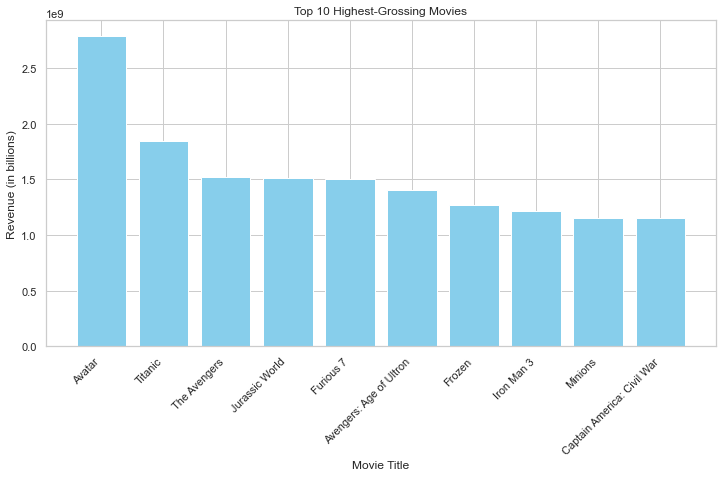

In [58]:
# Plotting a bar chart

plt.figure(figsize=(12, 6))
plt.bar(top_10_grossing_movies['title'], top_10_grossing_movies['revenue'], color='skyblue')
plt.xlabel('Movie Title')
plt.ylabel('Revenue (in billions)')
plt.title('Top 10 Highest-Grossing Movies')
plt.xticks(rotation=45, ha='right')
plt.show();

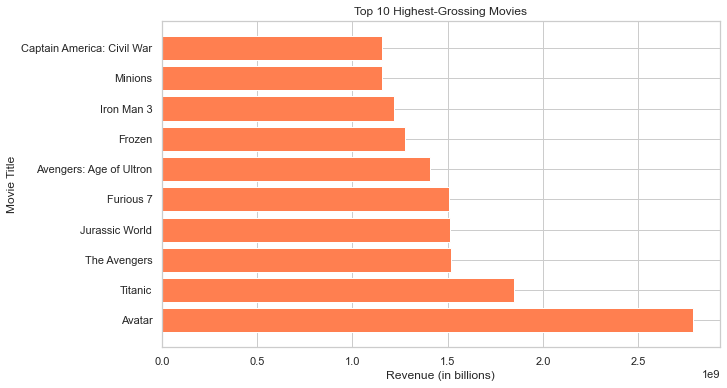

In [59]:
# Plotting a horizontal bar chart

plt.figure(figsize=(10, 6))
plt.barh(top_10_grossing_movies['title'], top_10_grossing_movies['revenue'], color='coral')
plt.xlabel('Revenue (in billions)')
plt.ylabel('Movie Title')
plt.title('Top 10 Highest-Grossing Movies')
plt.show();

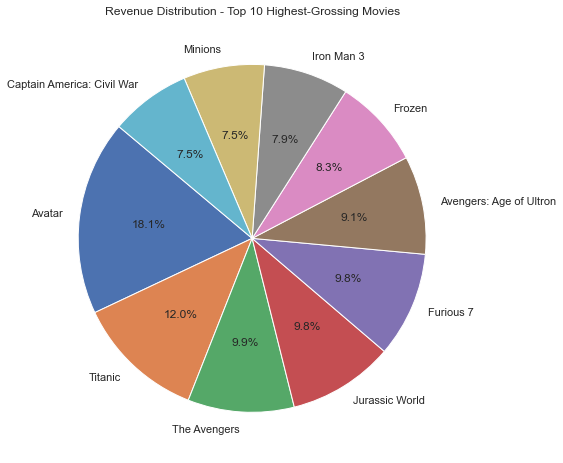

In [60]:
# Plotting a pie chart

plt.figure(figsize=(8, 8))
plt.pie(top_10_grossing_movies['revenue'], labels=top_10_grossing_movies['title'], autopct='%1.1f%%', startangle=140)
plt.title('Revenue Distribution - Top 10 Highest-Grossing Movies')
plt.show();

###### 8.	How does the budget correlate with the revenue?

###### To examine the correlation between budget and revenue, we can create a scatter plot. Additionally, we can calculate the correlation coefficient to quantify the strength and direction of the linear relationship between budget and revenue. 

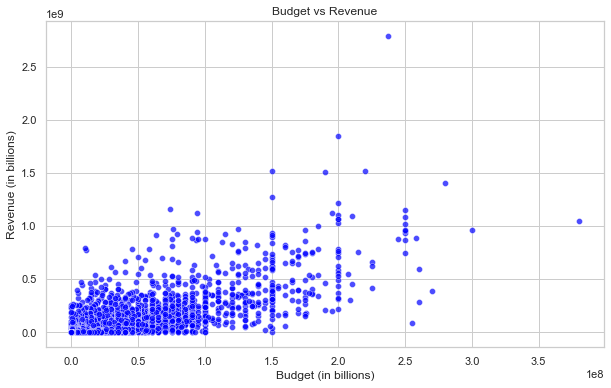

In [61]:
# Create a scatter plot

plt.figure(figsize=(10, 6))
sns.scatterplot(x='budget', y='revenue', data=df, color='blue', alpha=0.7)
plt.title('Budget vs Revenue')
plt.xlabel('Budget (in billions)')
plt.ylabel('Revenue (in billions)')
plt.show();

In [62]:
correlation_coefficient = df['budget'].corr(df['revenue'])
print(f'Correlation Coefficient between Budget and Revenue: {correlation_coefficient:.2f}')

# We can say that there is a strong positive correlation.

Correlation Coefficient between Budget and Revenue: 0.73


##### 9.	What are the most common keywords used in movie descriptions?

###### To find the most common keywords used in movie descriptions, we can use the CountVectorizer from scikit-learn

In [63]:
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
from wordcloud import WordCloud

In [64]:
descriptions = df['overview'].dropna().values

In [65]:
vectorizer = CountVectorizer(stop_words='english', max_features=50)
X = vectorizer.fit_transform(descriptions)

In [66]:
feature_names = vectorizer.get_feature_names_out()

In [67]:
word_counts = X.sum(axis=0).A1

In [68]:
# Create a dictionary with words and their counts

word_count_dict = dict(zip(feature_names, word_counts))

In [69]:
most_common_keywords = Counter(word_count_dict).most_common(10)

In [70]:
print('Top 10 most common keywords in movie descriptions:')
for keyword, count in most_common_keywords:
    print(f'{keyword}: {count} times')

Top 10 most common keywords in movie descriptions:
life: 870 times
new: 713 times
world: 629 times
young: 629 times
man: 582 times
family: 537 times
story: 444 times
love: 428 times
old: 367 times
father: 362 times


We should decorate it with a beautiful visual.

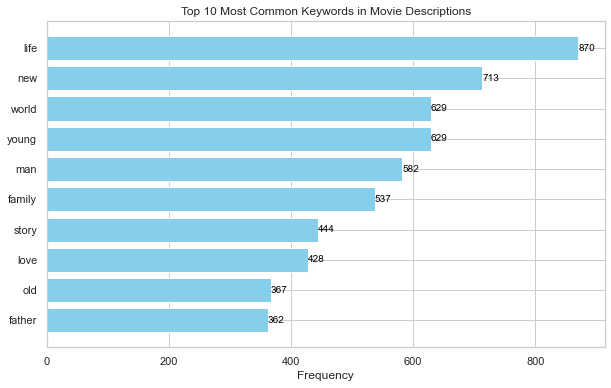

In [71]:
keywords, counts = zip(*most_common_keywords)

plt.figure(figsize=(10, 6))
bars = plt.barh(keywords, counts, color='skyblue')
plt.xlabel('Frequency')
plt.title('Top 10 Most Common Keywords in Movie Descriptions')
plt.gca().invert_yaxis()  # To display the highest count at the top

for bar, count in zip(bars, counts):
    plt.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, str(count), 
             va='center', ha='left', fontsize=10, color='black')

plt.show();

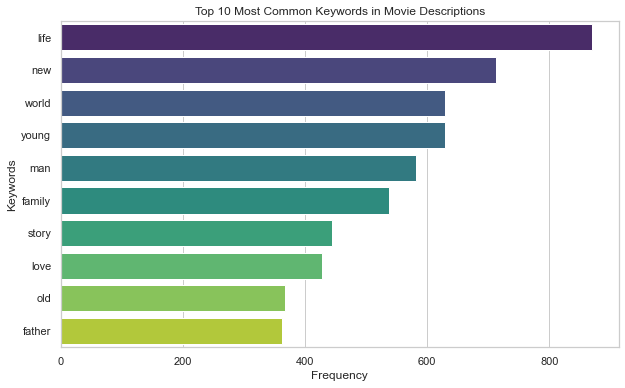

In [72]:
most_common_keywords_df = pd.DataFrame(most_common_keywords, columns=['keyword', 'count'])

plt.figure(figsize=(10, 6))
sns.barplot(x='count', y='keyword', data=most_common_keywords_df, palette='viridis')
plt.xlabel('Frequency')
plt.ylabel('Keywords')
plt.title('Top 10 Most Common Keywords in Movie Descriptions')

plt.show();

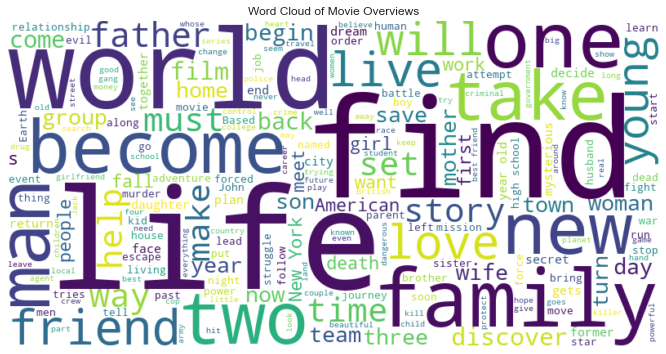

In [73]:
text = ' '.join(df_movies['overview'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Plot the WordCloud image
plt.figure(figsize=(16, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Movie Overviews')

plt.show();

#### 10.	What is the distribution of movie ratings?

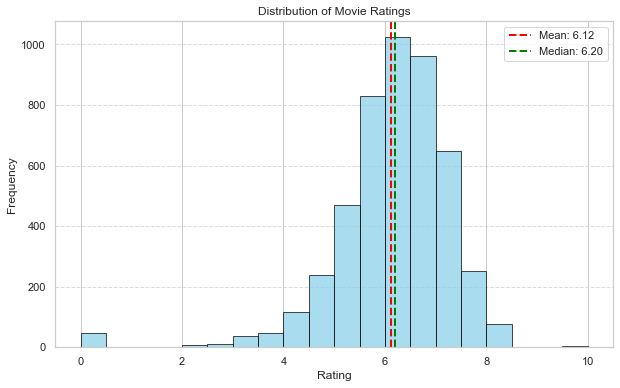

In [74]:
plt.figure(figsize=(10, 6))
plt.hist(df['vote_average'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adding vertical lines for mean and median
mean_rating = df['vote_average'].mean()
median_rating = df['vote_average'].median()

plt.axvline(mean_rating, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_rating:.2f}')
plt.axvline(median_rating, color='green', linestyle='dashed', linewidth=2, label=f'Median: {median_rating:.2f}')

plt.legend()
plt.show();

###### We can make a few more comparisons.

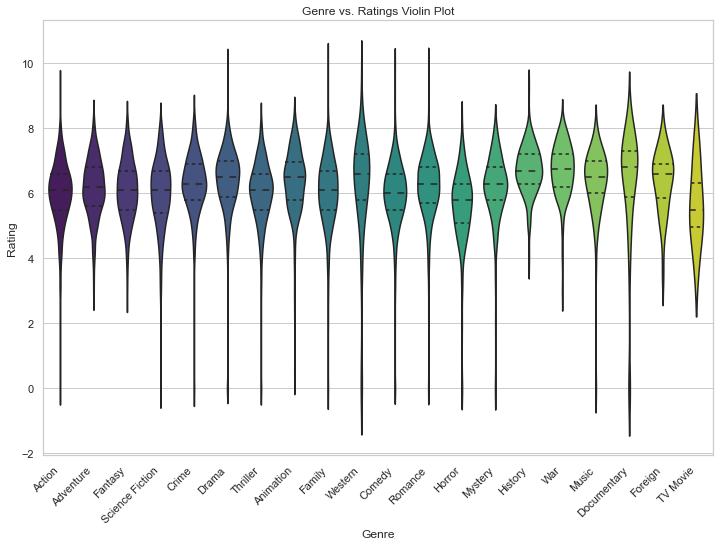

In [75]:
# Genre vs Ratings


plt.figure(figsize=(12, 8))
sns.violinplot(x='genres', y='vote_average', data=exploded_genres, palette='viridis', inner='quartile')
plt.title('Genre vs. Ratings Violin Plot')
plt.xlabel('Genre')
plt.ylabel('Rating')
plt.xticks(rotation=45, ha='right')
plt.show();

In [76]:
# Director vs. Ratings

exp_director = df.explode('director')

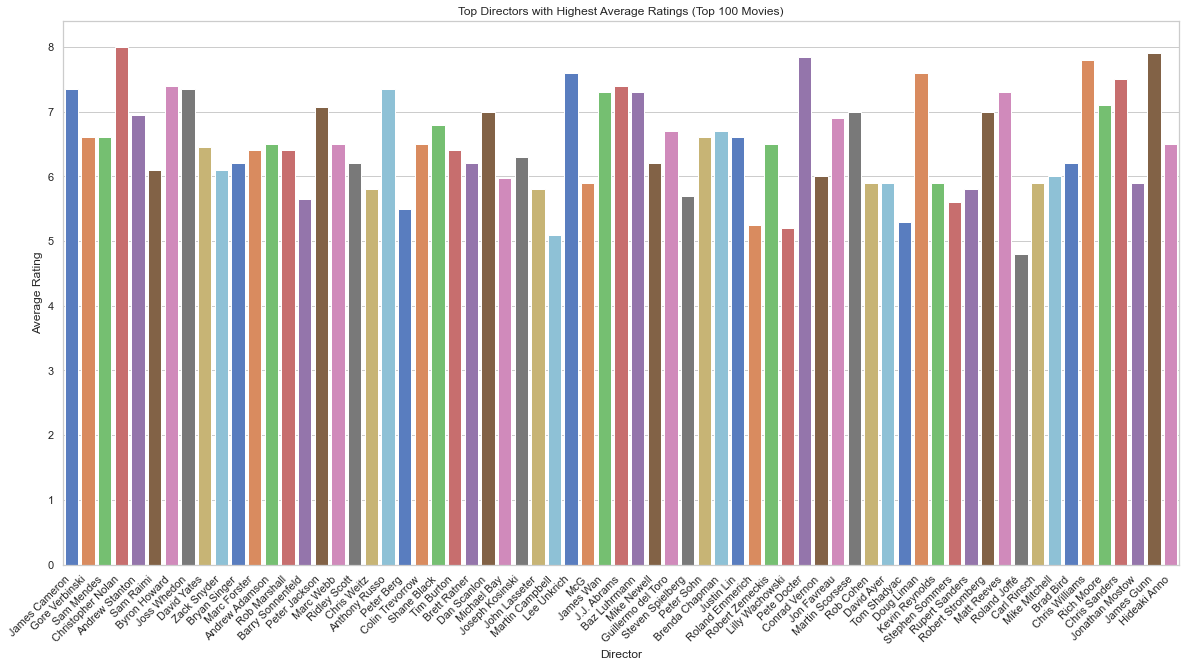

In [77]:
plt.figure(figsize=(20, 10))
sns.barplot(x='director', y='vote_average', data=exp_director.head(100), ci=None, palette='muted')
plt.title('Top Directors with Highest Average Ratings (Top 100 Movies)')
plt.xlabel('Director')
plt.ylabel('Average Rating')
plt.xticks(rotation=45, ha='right')
plt.show()

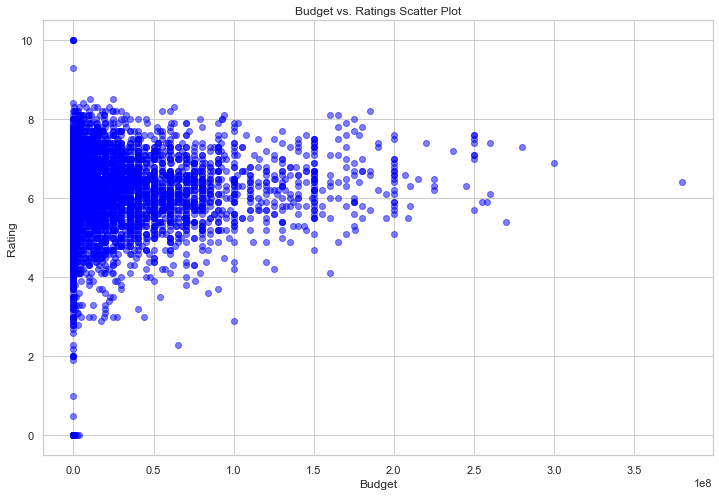

In [78]:
# Budget vs. Ratings

plt.figure(figsize=(12, 8))
plt.scatter(df_movies['budget'], df_movies['vote_average'], alpha=0.5, color='blue')
plt.title('Budget vs. Ratings Scatter Plot')
plt.xlabel('Budget')
plt.ylabel('Rating')
plt.show();

#### 11.	Are there any correlations between variables like budget, popularity, and revenue?

In [79]:
columns_to_correlate = ['budget', 'popularity', 'revenue']

In [80]:
correlation_matrix = df[columns_to_correlate].corr()

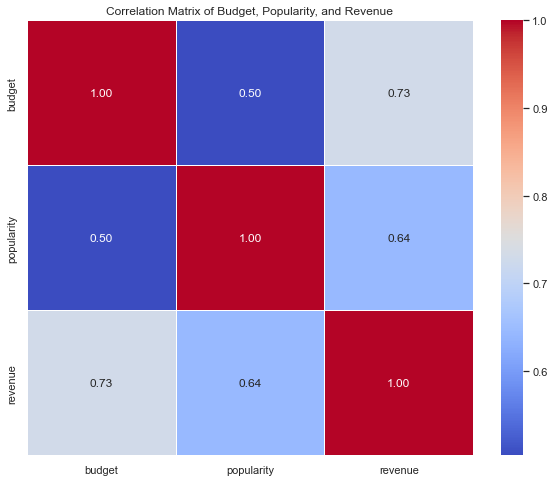

In [81]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Budget, Popularity, and Revenue')
plt.show();

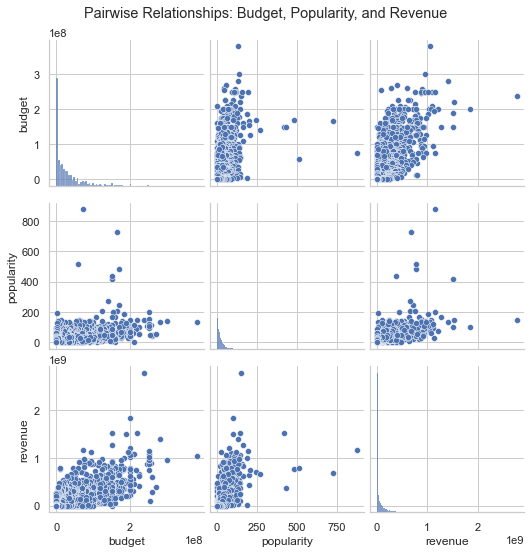

In [82]:
sns.pairplot(df_movies[columns_to_correlate])
plt.suptitle('Pairwise Relationships: Budget, Popularity, and Revenue', y=1.02)
plt.show();

#### 12.	What are the most common production countries for movies in the dataset?

In [83]:
# Explode the 'production_countries' column
exp_production_countries = df.explode('production_countries')

# Count occurrences of each country
country_counts = Counter(exp_production_countries['production_countries'])

# Get the most common countries
top_countries = country_counts.most_common()

# Display the top countries
print("Top 10 Most Common Production Countries:")
for country, count in top_countries[:10]:
    print(f"{country}: {count} movies")

Top 10 Most Common Production Countries:
United States of America: 3954 movies
United Kingdom: 636 movies
Germany: 324 movies
France: 306 movies
Canada: 261 movies
nan: 152 movies
Australia: 110 movies
Italy: 71 movies
Spain: 71 movies
China: 58 movies


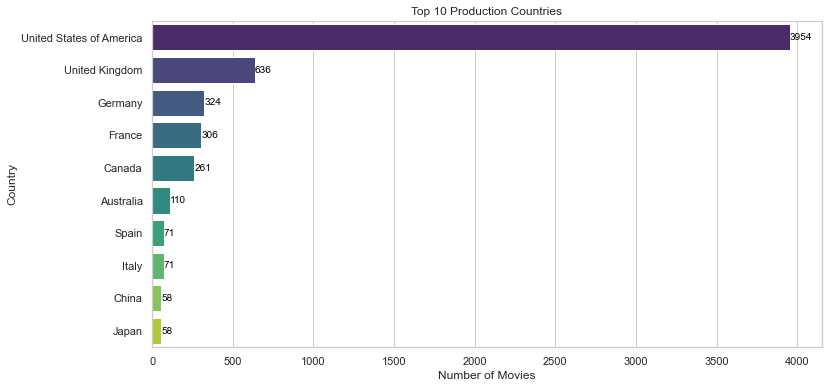

In [84]:
country_counts = exp_production_countries['production_countries'].value_counts()

# Select the top N countries for visualization
top_countries = country_counts.head(10)

# Plot the data
plt.figure(figsize=(12, 6))
bar_plot = sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')

for index, value in enumerate(top_countries.values):
    bar_plot.text(value, index, f'{value}', ha='left', va='center', color='black', fontsize=10)

plt.title('Top 10 Production Countries')
plt.xlabel('Number of Movies')
plt.ylabel('Country')


plt.show();

#### 13.	How many movies were released in each month of the year?

In [85]:
df['release_month'] = df['release_date'].dt.month

In [86]:
monthly_counts = df['release_month'].value_counts().sort_index()

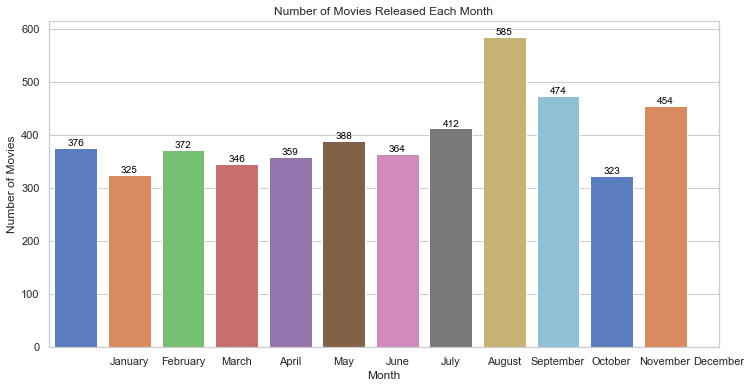

In [87]:
plt.figure(figsize=(12, 6))
bar_plot = sns.barplot(x=monthly_counts.index, y=monthly_counts.values, palette='muted')


for index, value in enumerate(monthly_counts.values):
    bar_plot.text(index, value, f'{value}', ha='center', va='bottom', color='black', fontsize=10)

plt.title('Number of Movies Released Each Month')
plt.xlabel('Month')
plt.ylabel('Number of Movies')
plt.xticks(ticks=range(1, 13), labels=[
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
])
plt.show();

#### 14.	What are the most common spoken languages in movies?

In [88]:
df['spoken_languages']

0                                    [English, Español]
1                                             [English]
2       [Français, English, Español, Italiano, Deutsch]
3                                             [English]
4                                             [English]
                             ...                       
4773                                                 []
4774                                          [Español]
4775                                                 []
4776                                          [English]
4777                                          [English]
Name: spoken_languages, Length: 4778, dtype: object

In [89]:
all_languages = [lang for sublist in df['spoken_languages'] for lang in sublist]

In [91]:
min_count = 50 
language_counts = pd.Series(all_languages).value_counts()
language_counts = language_counts[language_counts >= min_count]

C:\Users\USER\anaconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning:

Glyph 26222 (\N{CJK UNIFIED IDEOGRAPH-666E}) missing from current font.

C:\Users\USER\anaconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning:

Glyph 36890 (\N{CJK UNIFIED IDEOGRAPH-901A}) missing from current font.

C:\Users\USER\anaconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning:

Glyph 35805 (\N{CJK UNIFIED IDEOGRAPH-8BDD}) missing from current font.

C:\Users\USER\anaconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning:

Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from current font.

C:\Users\USER\anaconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning:

Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from current font.

C:\Users\USER\anaconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning:

Glyph 35486 (\N{CJK UNIFIED IDEOGRAPH-8A9E}) missing from current font.



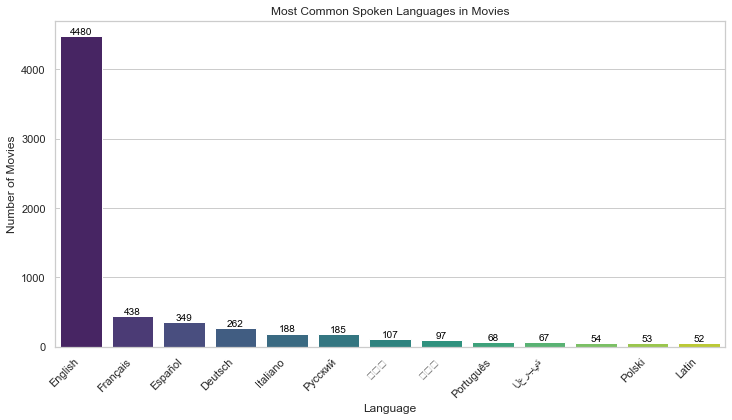

In [92]:
plt.figure(figsize=(12, 6))
bar_plot = sns.barplot(x=language_counts.index, y=language_counts.values, palette='viridis')

# Add numeric values on the bars
for index, value in enumerate(language_counts.values):
    bar_plot.text(index, value, f'{value}', ha='center', va='bottom', color='black', fontsize=10)

plt.title('Most Common Spoken Languages in Movies')
plt.xlabel('Language')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45, ha='right')
plt.show();

#### 15.	Are there any patterns in the runtime of movies over the years?

In [93]:
average_runtime_by_year = df.groupby('release_year')['runtime'].mean().reset_index()

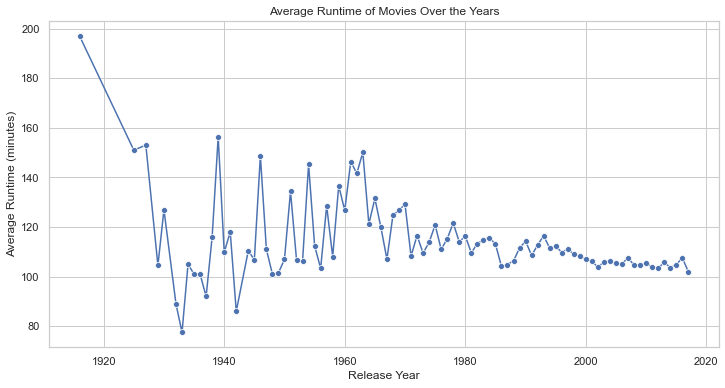

In [94]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='release_year', y='runtime', data=average_runtime_by_year, marker='o')

plt.xlabel('Release Year')
plt.ylabel('Average Runtime (minutes)')
plt.title('Average Runtime of Movies Over the Years')

plt.show();

#### 16.	Is there a correlation between the number of votes a movie receives and its revenue?

In [95]:
df_votes_revenue = df[['vote_count', 'revenue']].dropna()

In [96]:
# Calculate the correlation coefficient

correlation_coefficient = df_votes_revenue['vote_count'].corr(df_votes_revenue['revenue'])

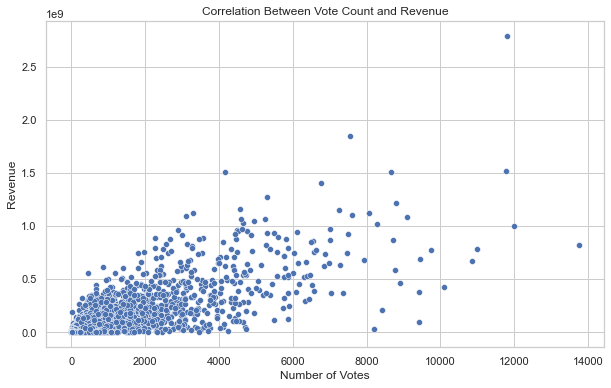

Correlation Coefficient: 0.7810752584121552


In [97]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='vote_count', y='revenue', data=df_votes_revenue)
plt.title('Correlation Between Vote Count and Revenue')
plt.xlabel('Number of Votes')
plt.ylabel('Revenue')
plt.show()

# Display the correlation coefficient
print(f"Correlation Coefficient: {correlation_coefficient}")

#### 17.	How does the popularity of movies vary based on their genres?

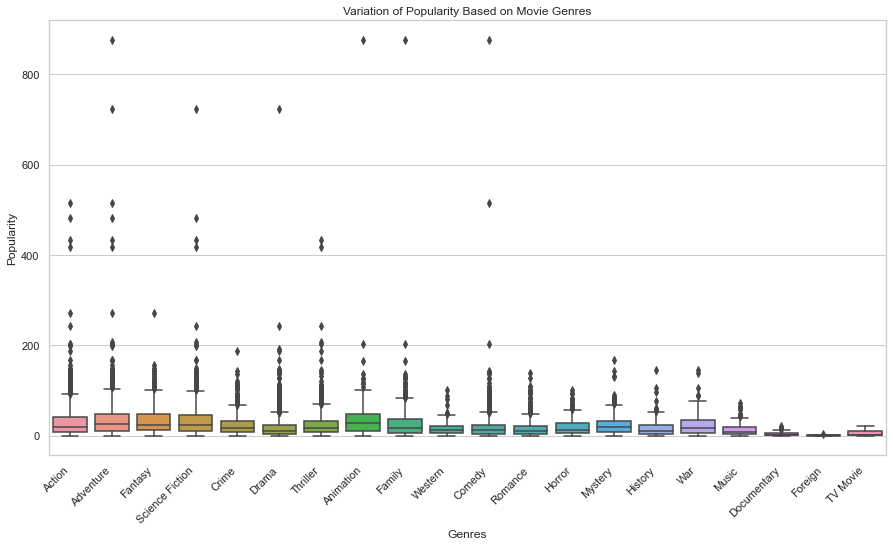

In [98]:
plt.figure(figsize=(15, 8))
sns.boxplot(x='genres', y='popularity', data=exploded_genres)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.title('Variation of Popularity Based on Movie Genres')
plt.xlabel('Genres')
plt.ylabel('Popularity')
plt.show();

In [ ]:
In this plot:

Each point represents a movie, and the distribution of these points provides insights into popularity scores for each genre.
The dashed red line and points represent the average popularity for each genre, offering a quick reference for central tendency.

C:\Users\USER\anaconda3\lib\site-packages\seaborn\categorical.py:1296: UserWarning:

91.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

C:\Users\USER\anaconda3\lib\site-packages\seaborn\categorical.py:1296: UserWarning:

86.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

C:\Users\USER\anaconda3\lib\site-packages\seaborn\categorical.py:1296: UserWarning:

80.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

C:\Users\USER\anaconda3\lib\site-packages\seaborn\categorical.py:1296: UserWarning:

82.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

C:\Users\USER\anaconda3\lib\site-packages\seaborn\categorical.py:1296: UserWarning:

89.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

C:\Users\USER\anaconda3\lib\site-packages\sea

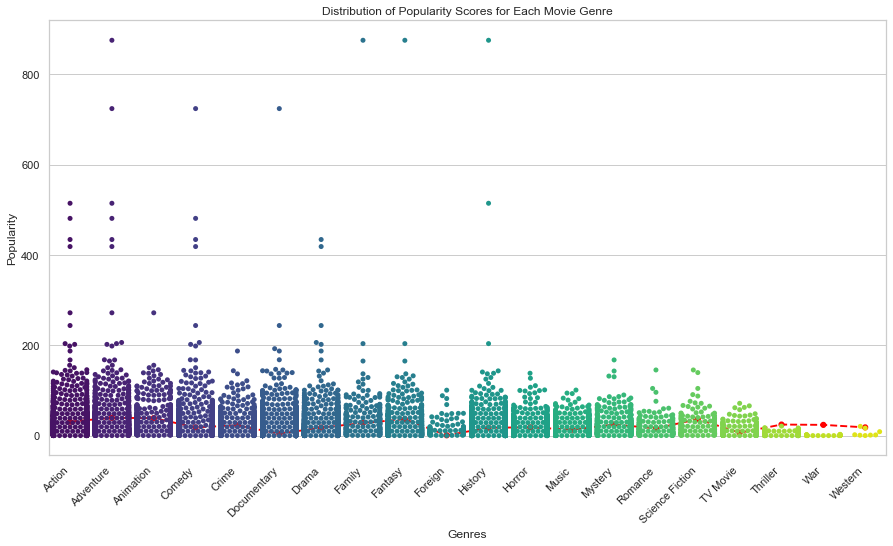

In [99]:
avg_popularity_per_genre = exploded_genres.groupby('genres')['popularity'].mean().reset_index()

# Create a swarm plot with color-coded average popularity
plt.figure(figsize=(15, 8))
sns.swarmplot(x='genres', y='popularity', data=exploded_genres, palette='viridis', size=5)
sns.pointplot(x='genres', y='popularity', data=avg_popularity_per_genre, color='red', markers='o', linestyles='dashed', scale=0.7)

plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.title('Distribution of Popularity Scores for Each Movie Genre')
plt.xlabel('Genres')
plt.ylabel('Popularity')
plt.show();

#### 18.	Which actors have appeared in the most movies?

In [111]:
df.cast

0       [{"cast_id": 242, "character": "Jake Sully", "...
1       [{"cast_id": 4, "character": "Captain Jack Spa...
2       [{"cast_id": 1, "character": "James Bond", "cr...
3       [{"cast_id": 2, "character": "Bruce Wayne / Ba...
4       [{"cast_id": 5, "character": "John Carter", "c...
                              ...                        
4773                                                   []
4774    [{"cast_id": 1, "character": "El Mariachi", "c...
4775    [{"cast_id": 1, "character": "Buzzy", "credit_...
4776    [{"cast_id": 8, "character": "Oliver O\u2019To...
4777    [{"cast_id": 3, "character": "Herself", "credi...
Name: cast, Length: 4778, dtype: object

In [113]:
from ast import literal_eval

# Assuming 'cast' column is already converted to list format
df['cast'] = df['cast'].apply(lambda x: literal_eval(x) if pd.notnull(x) else [])
df['actors'] = df['cast'].apply(lambda x: [entry['name'] for entry in x] if x else [])

# Explode the 'actors' column to have one actor per row
df_actors = df.explode('actors')

# Count the number of appearances for each actor
actor_appearances = df_actors['actors'].value_counts().reset_index()

# Rename the columns for clarity
actor_appearances.columns = ['Actor', 'Number of Appearances']

# Display the top 10 actors with the most appearances
top_actors = actor_appearances.head(10)
print(top_actors)

               Actor  Number of Appearances
0  Samuel L. Jackson                     67
1     Robert De Niro                     57
2       Bruce Willis                     51
3         Matt Damon                     48
4     Morgan Freeman                     46
5      Steve Buscemi                     43
6        Liam Neeson                     41
7        Owen Wilson                     40
8        Johnny Depp                     40
9       Nicolas Cage                     39


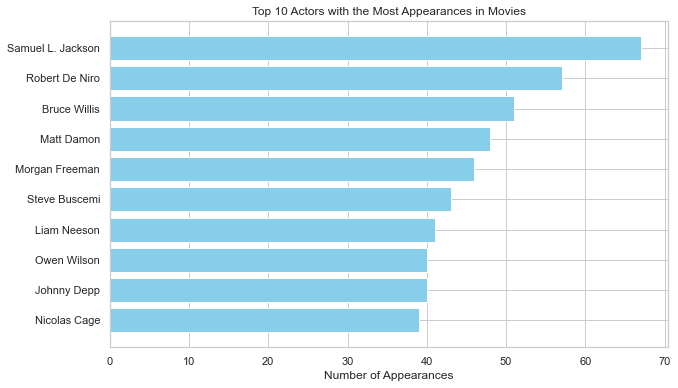

In [114]:
plt.figure(figsize=(10, 6))
plt.barh(top_actors['Actor'], top_actors['Number of Appearances'], color='skyblue')
plt.xlabel('Number of Appearances')
plt.title('Top 10 Actors with the Most Appearances in Movies')
plt.gca().invert_yaxis()  # To have the actor with the most appearances at the top
plt.show();

#### 19.	What is the distribution of movie release days in a week?

In [115]:
# Extract the day of the week from the 'release_date' column

df['release_day'] = df['release_date'].dt.day_name()

In [116]:
release_day_counts = df['release_day'].value_counts()

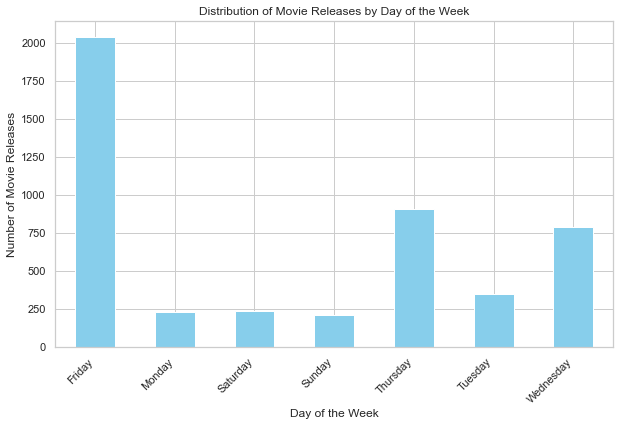

In [117]:
plt.figure(figsize=(10, 6))
release_day_counts.sort_index().plot(kind='bar', color='skyblue')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Movie Releases')
plt.title('Distribution of Movie Releases by Day of the Week')
plt.xticks(rotation=45, ha='right')  
plt.show();

#### 20.	How does the revenue and popularity vary for different production companies?

In [123]:
df.revenueue

0       2787965087
1        961000000
2        880674609
3       1084939099
4        284139100
           ...    
4773             0
4774       2040920
4775             0
4776             0
4777             0
Name: revenue, Length: 4778, dtype: int64

In [124]:
df.popularity

0       150.437577
1       139.082615
2       107.376788
3       112.312950
4        43.926995
           ...    
4773      0.022173
4774     14.269792
4775      0.642552
4776      1.444476
4777      1.929883
Name: popularity, Length: 4778, dtype: float64

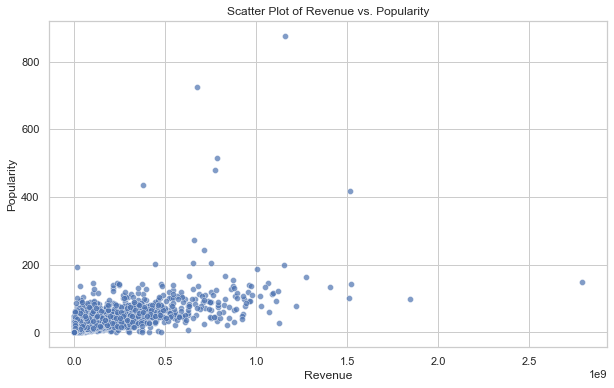

In [125]:
# Scatter plot for Revenue vs. Popularity
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_movies, x='revenue', y='popularity', alpha=0.7)
plt.title('Scatter Plot of Revenue vs. Popularity')
plt.xlabel('Revenue')
plt.ylabel('Popularity')
plt.show();

### Title: Exploratory Data Analysis on a Movie Dataset

#### Introduction:
In this analysis, we embarked on a journey to explore and derive insights from a movie dataset. The dataset, containing information about various movies, provided a rich source for understanding trends, patterns, and correlations within the film industry.

#### Data Cleaning:
Our initial step involved cleaning the dataset to ensure its integrity and suitability for analysis. This encompassed handling missing values, converting data types, and addressing inconsistencies in columns such as 'genres,' 'cast,' 'crew,' and 'production_countries.'

#### Feature Engineering:
To enhance our analysis, we performed feature engineering by extracting valuable information from columns like 'cast' and 'crew.' This involved creating new columns such as 'actors,' 'directors,' and 'production_companies' to facilitate a more granular exploration.

### Exploratory Data Analysis (EDA):

#### Directorial Impact: 
We investigated the influence of directors on movie ratings. A new 'director' column was created, and directors with the highest average ratings were identified using groupby and sorting techniques. Visualizations such as bar charts were employed to present these findings.

#### Genre Trends: 
Leveraging the list format of the 'genres' column, we explored trends in movie genres over the years. This involved counting genre occurrences and visualizing the results using bar plots.

#### Revenue and Popularity Patterns:
Correlations between revenue and popularity for different production companies were examined. Heatmaps and scatter plots provided visual insights into how these variables interact within the industry.

#### Top 10 Movies: 
We identified and visualized the top 10 highest-grossing movies, offering a snapshot of the most financially successful films.

#### Budget vs. Revenue Relationship: 
To understand the relationship between budget and revenue, we utilized scatter plots to visualize how these two factors correlate.

#### Keyword Analysis: 
We delved into the most common keywords used in movie descriptions, presenting the results through word clouds that visually highlighted keyword frequency.

#### Movie Ratings Distribution: 
The distribution of movie ratings was explored using histograms, offering insights into the overall sentiment of the movies in the dataset.

#### Monthly Release Patterns: 
We investigated trends in movie releases throughout the year, uncovering any patterns or seasonality in the industry.

#### Language Distribution: 
Analyzing the most common spoken languages in movies, we visualized language occurrences while considering readability by eliminating less frequent languages.

#### Runtime Patterns: 
Patterns in movie runtimes over the years were examined, providing insights into potential shifts in audience preferences.

### Conclusion:
Through systematic data cleaning, thoughtful feature engineering, and strategic EDA, we successfully answered a diverse set of 20 questions. The use of Python, Pandas, Matplotlib, and Seaborn allowed for efficient analysis and visualization, demonstrating the power of exploratory data analysis in gaining valuable insights from complex datasets.